# TealQL playground — the full analysis stack, on one contract

Edit the TEAL in **Cell 1**, run **Cell 2** (setup), then run any section below. Everything
is reconstructed in-process from `.teal` source — pure Python, no database, no build step.
The sample `vault` app is deliberately small but exercises every layer: ABI method routing,
a per-account box map, an owner-guarded inner-payment, ARC-4 typed args, and a real finding.

| Section | What it shows |
|---|---|
| 1–2 | Source + setup (typed SSA reconstruction) |
| 3 | **SSA** functional form with IntRange / byte-length overlays |
| 4 | **Security detectors** (36, auto-discovered) — findings |
| 5 | **Type-driven audits** — abi-audit / box-audit |
| 6 | **Puya-IR lift** — genuine `puya.ir.models` |
| 7 | **Type recovery** — ARC-4 encodings, confident vs speculative |
| 8 | **Storage schema** — global/local/box keys & maps (Puya `ContractState`) |
| 9 | Cost · path predicates · inner-txn report |
| 10 | The complete dump (every representation) |


## 1. TEAL source  — *edit me, then re-run Cell 2*


In [1]:
TEAL_SOURCE = r"""
#pragma version 10
// ── Vault: a method-routed ABI app with per-account box balances and an
//    owner-guarded payout. Deliberately small, but exercises every layer.

txn ApplicationID
bz on_create

txna ApplicationArgs 0
method "deposit()void"
==
bnz deposit
txna ApplicationArgs 0
method "withdraw(address,uint64)void"
==
bnz withdraw
err

on_create:
byte "name"
byte 0x000556617563                 // arc4.String "Vault"
app_global_put
int 1
return

// deposit(): credit a per-account balance box keyed by the caller.
deposit:
byte "bal"
txn Sender
concat                              // box[ "bal" ++ Sender ] : per-account map
int 8
box_create
pop
int 1
return

// withdraw(address recipient, uint64 amount): owner-only payout.
withdraw:
callsub require_owner
txna ApplicationArgs 1
extract 2 32                        // the arc4.address recipient
txna ApplicationArgs 2
btoi                                // the uint64 amount
callsub pay
int 1
return

// pay(recipient: bytes[32], amount: uint64)
pay:
proto 2 0
itxn_begin
int pay
itxn_field TypeEnum
frame_dig -2
itxn_field Receiver
frame_dig -1
itxn_field Amount
itxn_submit
retsub

// require_owner(): assert the caller is the app creator.
require_owner:
proto 0 0
txn Sender
global CreatorAddress
==
assert
retsub
"""


## 2. Setup — reconstruct typed SSA from the source


In [2]:
import logging, sys, tempfile, importlib
logging.getLogger("puya").setLevel(logging.CRITICAL)   # silence lift/compiler chatter
from pathlib import Path

# Force-reload tealql if you edited its source between runs.
for m in [x for x in sys.modules if x == 'tealql' or x.startswith('tealql.')]: del sys.modules[m]

REPO = Path.cwd().parent if Path.cwd().name == 'playground' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))
SRC = Path(tempfile.mkdtemp()) / 'vault.teal'
SRC.write_text(TEAL_SOURCE.lstrip())

from tealql.tealtools.ssa import SSAProgram
prog = SSAProgram(str(SRC))
print(f'SSA reconstructed: {len(prog.assignments)} assignments, {len(prog.blocks)} basic blocks, {len(prog.phis)} phis')
HAVE_LIFT = importlib.util.find_spec('puya') is not None
print('lift/type-recovery available (puya installed):', HAVE_LIFT)


SSA reconstructed: 48 assignments, 13 basic blocks, 0 phis
lift/type-recovery available (puya installed): True


## 3. Typed SSA — functional form with analytical overlays

The substrate everything else consumes. `/*[V<=hi]*/` = a recovered uint64 `IntRange`;
`/*len=N*/` = a proven byte-length. Note the ABI method selectors already recovered as
constants (`0x92e03b1c` = `deposit()void`).


In [3]:
from tealql.tealtools.passes import functional_dump
print(functional_dump(prog, show_ranges=True, show_bytes=True))


L   5: V#1@L5 = txn ApplicationID ()
L   6: bz on_create (V#1@L5)
L   8: V#1@L8 = txna ApplicationArgs 0 ()
L   9: V#1@L9 = pushbytes 0x92e03b1c ()
L  10: V#1@L10 /*[V#1@L10<=1]*/ = == (0x92e03b1c, V#1@L8)
L  11: bnz deposit (V#1@L10 /*[V#1@L10<=1]*/)
L  13: V#1@L13 = pushbytes 0x13ff1ce9 ()
L  14: V#1@L14 /*[V#1@L14<=1]*/ = == (0x13ff1ce9, V#1@L8)
L  15: bnz withdraw (V#1@L14 /*[V#1@L14<=1]*/)
L  16: err ()
L  18: on_create:
L  19: V#1@L19 = pushbytes 0x6e616d65 ()
L  20: V#1@L20 = pushbytes 0x000556617563 ()
L  21: app_global_put (0x000556617563, 0x6e616d65)
L  23: return ()
L  26: deposit:
L  27: V#1@L27 = pushbytes 0x62616c ()
L  28: V#1@L28 /*len=32*/ = txn Sender ()
L  29: V#1@L29 /*len=35*/ = concat (V#1@L28 /*len=32*/, 0x62616c)
L  30: V#1@L30 /*[V#1@L30=8]*/ = int 8 ()
L  31: V#1@L31 = box_create (8, V#1@L29 /*len=35*/)
L  32: pop (V#1@L31)
L  34: return ()
L  37: withdraw:
L  38: callsub require_owner ()
L  39: V#1@L39 /*34<=len<=4096*/ = txna ApplicationArgs 1 ()
L  41: V#1@

## Graph representations — rendered inline (Graphviz SVG)

The same reconstructions, drawn. The **basic-block CFG** (control flow over BBs, with the
opcodes in each block) and the **control tree** (the recovered region structure —
if / switch / loop nesting the decompiler infers from the CFG). `dump_all(src, out_dir=...)`
also writes `graph`/`cfg`/`ssa`/`supercfg` `.svg` files to disk.


## 4. Security detectors

36 detectors, auto-discovered, each scored against a ground-truth corpus. The SSA-level
detectors plus an interprocedural `ir-*` family that runs on the lifted IR (guard dominance
across `callsub` is precise there).


In [5]:
from tealql.security import DETECTORS
any_found = False
for name in sorted(DETECTORS):
    try:
        findings = DETECTORS[name](prog).detect()
    except Exception as e:
        continue
    if findings:
        any_found = True
        print(f'### {name}')
        for v in findings: print('   ', v.pretty())
print('(no findings)' if not any_found else '')


### abi-method-selector
    Approval exit at vault.teal:23 is reachable without validating the ABI method selector (txna ApplicationArgs 0) — unrecognised methods are not rejected.
### asset-close-to
    Contract does not validate txn AssetCloseTo — all asset units can be drained from the account.
### close-remainder-to
    Approval exit at vault.teal:23 is reachable without a CloseRemainderTo check — the account's entire ALGO balance can be drained.
    Approval exit at vault.teal:34 is reachable without a CloseRemainderTo check — the account's entire ALGO balance can be drained.
    Approval exit at vault.teal:45 is reachable without a CloseRemainderTo check — the account's entire ALGO balance can be drained.
### delete-funds-check
    Application handles DeleteApplication at exit vault.teal:23 without checking balance == min_balance — funds may be locked permanently on deletion.
    Application handles DeleteApplication at exit vault.teal:34 without checking balance == min_balance —

### ir-tainted-fund-flow
    [HIGH] attacker-controlled itxn Receiver <- ApplicationArgs (vault.teal:54, pay); no dominating check of the value or txn Sender (IR interprocedural)  via: txna ApplicationArgs 1 @L39  →  extract 2 32 @L40
    [MEDIUM] attacker-controlled itxn Amount <- ApplicationArgs (vault.teal:56, pay); no dominating check of the value or txn Sender (IR interprocedural)  via: txna ApplicationArgs 2 @L41  →  btoi @L42
### is-deletable
    Application is deletable at exit vault.teal:23: OnCompletion == DeleteApplication can reach approval without a guard.
    Application is deletable at exit vault.teal:34: OnCompletion == DeleteApplication can reach approval without a guard.
    Application is deletable at exit vault.teal:45: OnCompletion == DeleteApplication can reach approval without a guard.
### is-updatable
    Application is updatable at exit vault.teal:23: OnCompletion == UpdateApplication can reach approval without a guard.
    Application is updatable at exit vaul

## 5. Type-driven security audits *(need the lift)*

Built on the recovered ARC-4 types. **abi-audit**: a caller-supplied `arc4.Address` paid to a
fund sink unguarded. **box-audit**: an address-keyed BoxMap not bound to `txn Sender`
(cross-user access) — here the box IS Sender-keyed, so correctly clean.


In [6]:
if HAVE_LIFT:
    from tealql.tealtools.lift import to_puya
    from tealql.tealtools.lift.to_puya_ir import abi_address_fund_flows
    from tealql.tealtools.lift.box_recovery import box_access_control
    main, subs = to_puya(SSAProgram(str(SRC)))
    print('=== abi-audit (recovered arc4.Address at fund sinks) ===')
    leads = abi_address_fund_flows(main, subs)
    for x in leads: print('  ', x)
    if not leads: print('   (no address reaches a fund sink)')
    print('\n=== box-audit (cross-user box access) ===')
    acl = box_access_control(main, subs)
    for f in acl: print('  ', f.render())
    if not acl: print('   (no cross-user box-access leads)')
else: print('install puya for the lift-based audits')


=== abi-audit (recovered arc4.Address at fund sinks) ===
   {'field': 'Receiver', 'subroutine': 'pay', 'encoding': 'Encoded(uint8[32])', 'confident': True, 'caller_supplied': False, 'guarded': False}

=== box-audit (cross-user box access) ===
   (no cross-user box-access leads)


## 6. Puya-IR lift — genuine `puya.ir.models`

The reconstructed SSA lowered into real Puya IR, validated & optimised by Puya's own passes
(not a re-implementation). Behaviourally verified against ~900 mainnet contracts.


In [7]:
if HAVE_LIFT:
    from tealql.tealtools.lift import to_puya_ir
    print(to_puya_ir.render(SSAProgram(str(SRC)), optimize_ir=False))
else: print('install puya for the lift')


main vault.teal:
    block@0: // L5
        let tmp%0#0: uint64 = (txn ApplicationID)
        goto tmp%0#0 ? block@1 : block@4
    block@1: // L8
        let tmp%1#0: bytes = (txna ApplicationArgs 0)
        let eq%0#0: bool = (== tmp%1#0 0x92e03b1c)
        goto eq%0#0 ? block@5 : block@2
    block@2: // L12
        let tmp%2#0: bytes = (txna ApplicationArgs 0)
        let eq%1#0: bool = (== tmp%2#0 0x13ff1ce9)
        goto eq%1#0 ? block@6 : block@3
    block@3: // L16
        fail // err
    block@4: // L18
        (app_global_put 0x6e616d65 0x000556617563)
        exit 1u
    block@5: // L26
        let tmp%3#0: account = (txn Sender)
        let concat%0#0: bytes[35] = (concat 0x62616c tmp%3#0)
        let tmp%4#0: bool = (box_create concat%0#0 8u)
        exit 1u
    block@6: // L37
        require_owner()
        goto block@7
    block@7: // L39
        let tmp%5#0: bytes = (txna ApplicationArgs 1)
        let tmp%6#0: bytes[32] = ((extract 2 32) tmp%5#0)
        let tmp%7#0: by

## 7. Type recovery — ARC-4 encodings recovered from byte idioms

Types erased by compilation, recovered from the wire idioms. Two tiers: **confident** (the
idiom's proof forces the type) vs **speculative** (a shape that fits). Note the `uint8[32]`
= `arc4.Address` recipient, and the `arc4.String` global.


In [8]:
if HAVE_LIFT:
    import puya.ir.models as M
    from tealql.tealtools.lift import to_puya_ir
    main, subs = to_puya_ir.to_puya(SSAProgram(str(SRC)))
    guesses, confident = to_puya_ir.guess_encoded_types_scored(main, subs)
    n_sure = sum(1 for v in confident.values() if v)
    print(f'{len(guesses)} ARC-4 guess(es): {n_sure} fully confident, {len(guesses)-n_sure} speculative')
    for rid, et in guesses.items():
        tag = 'confident' if confident.get(rid) else 'speculative'
        print(f'   [{tag:11}] {et.encoding}')
else: print('install puya for type recovery')


1 ARC-4 guess(es): 1 fully confident, 0 speculative
   [confident  ] uint8[32]


## 8. Storage schema — reconstructed `ContractState` (global / local / box)

Reconstructs Puya's own storage model — single keys vs maps, with recovered key/value types
including composite tuple keys. This ARC-56 schema is **not in the deployed bytecode**.


In [9]:
if HAVE_LIFT:
    from tealql.tealtools.lift.box_recovery import recover_storage_schema
    from tealql.tealtools.lift import to_puya
    main, subs = to_puya(SSAProgram(str(SRC)))
    for s in recover_storage_schema(main, subs): print('  ', s.render())
else: print('install puya for storage-schema recovery')


   box map prefix='bal' key=address value=bytes  [box_create]
   global key='name' value=byte[6]  [app_global_put]


## 9. More reports — cost · path predicates · inner-txn


## 10. The complete dump — every representation at once

`dump_all` aggregates all 14 layers (source, graph, CFG, SSA, taint, structure, control tree,
path predicates, inner-txn, Puya IR, ABI encodings, security leads, storage schema).


In [11]:
from tealql.tealtools.viz.dump import dump_all
print(dump_all(str(SRC)))


=== SOURCE (normalized TEAL)
#pragma version 10
// ── Vault: a method-routed ABI app with per-account box balances and an
//    owner-guarded payout. Deliberately small, but exercises every layer.

txn ApplicationID
bz on_create

txna ApplicationArgs 0
method "deposit()void"
==
bnz deposit
txna ApplicationArgs 0
method "withdraw(address,uint64)void"
==
bnz withdraw
err

on_create:
byte "name"
byte 0x000556617563                 // arc4.String "Vault"
app_global_put
int 1
return

// deposit(): credit a per-account balance box keyed by the caller.
deposit:
byte "bal"
txn Sender
concat                              // box[ "bal" ++ Sender ] : per-account map
int 8
box_create
pop
int 1
return

// withdraw(address recipient, uint64 amount): owner-only payout.
withdraw:
callsub require_owner
txna ApplicationArgs 1
extract 2 32                        // the arc4.address recipient
txna ApplicationArgs 2
btoi                                // the uint64 amount
callsub pay
int 1
return

// pay(re

## 11. Cross-contract super-CFG

The analysis follows inner application calls ACROSS contract boundaries. Given a registry
`{app_id: .teal}`, it resolves each appcall with a constant `ApplicationID`, splices the
callees into one **super-CFG**, and runs the detectors on every hop (caller-pinned
ApplicationArgs are treated as trusted; path predicates propagate). Here a `router` calls a
`vault` (app 100) and a `payer` (app 200); the payer pays a caller-supplied Receiver.


3 contracts spliced; 4 inter-contract edges:
   call    root:L4-L11  ->  app100:L3-L10
   return  app100:L3-L10  ->  root:L12-L17
   call    root:L12-L17  ->  app200:L3-L10
   return  app200:L11-L12  ->  root:L18-L19



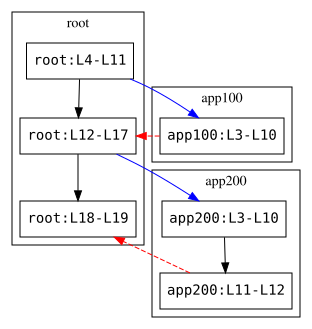

cross-contract auth findings:
    box_create@vault.teal:7  (state-mutating op)  preds: <no guard>
    itxn_submit@payer.teal:10  (state-mutating op)  preds: <no guard>



In [12]:
from IPython.display import SVG, display
from tealql.tealtools.cfg import SuperCFG
from tealql.tealtools.xcontract import XContractGraph, cross_auth_findings
from tealql.tealtools._utils.dot import render as _dot_render

XC = REPO / 'playground' / 'interactive-examples' / 'contracts' / 'xcontract'
registry = {100: str(XC / 'vault.teal'), 200: str(XC / 'payer.teal')}
router = SSAProgram(str(XC / 'router.teal'))

sc = SuperCFG.build(router, registry)
contracts = sorted({b.app_id for b in sc.blocks()}, key=lambda x: (x is not None, x))
print(f'{len(contracts)} contracts spliced; {len(sc.inter_edges)} inter-contract edges:')
for e in sc.inter_edges: print(f'   {e.kind:6}  {e.src}  ->  {e.dst}')
print()
display(SVG(data=bytes(_dot_render(sc.to_dot()))))

# Cross-contract detections: run the detector suite across the boundary.
g = XContractGraph.build(router, registry)
print('cross-contract auth findings:')
af = list(cross_auth_findings(g))
for f in af: print('   ', f.violation.pretty())
print('   (none)' if not af else '')
